## **Plantilla**

In [2]:
import pandas as pd

ruta = "https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv"
df = pd.read_csv(ruta)

model_cols = [
    "subscription_type",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "payment_method"
]

X = df[model_cols]
y = df["churned"]

X.head(), y.value_counts(normalize=True)


(  subscription_type  watch_hours  last_login_days  monthly_fee  \
 0             Basic        14.73               29         8.99   
 1          Standard         0.70               19        13.99   
 2          Standard        16.32               10        13.99   
 3           Premium         4.51               12        17.99   
 4          Standard         1.89               13        13.99   
 
    number_of_profiles  avg_watch_time_per_day payment_method  
 0                   1                    0.49      Gift Card  
 1                   5                    0.03      Gift Card  
 2                   2                    1.48         Crypto  
 3                   2                    0.35         Crypto  
 4                   2                    0.13         Crypto  ,
 churned
 1    0.503
 0    0.497
 Name: proportion, dtype: float64)

## **Importar lo necesario**

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier as RandomForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay



## **Definir columnas por tipo**



In [4]:
categorical_cols = ["subscription_type","payment_method"]
numeric_cols = [
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]


## **Crear el preprocesador**

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


## **Train/Test split (80/20)**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((4000, 7), (1000, 7))

## **Armar el pipeline**

In [7]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

## **Entrenar**

In [8]:
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subscription_type',
                                                   'payment_method']),
                                                 ('num', 'passthrough',
                                                  ['watch_hours',
                                                   'last_login_days',
                                                   'monthly_fee',
                                                   'number_of_profiles',
                                                   'avg_watch_time_per_day'])])),
                ('model', LogisticRegression(max_iter=1000))])

## **Evaluar**

### Reporte de clasificación

In [9]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.88      0.89       497
           1       0.88      0.91      0.90       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



### Matriz de confusión

In [10]:
print(confusion_matrix(y_test, y_pred))

[[436  61]
 [ 45 458]]


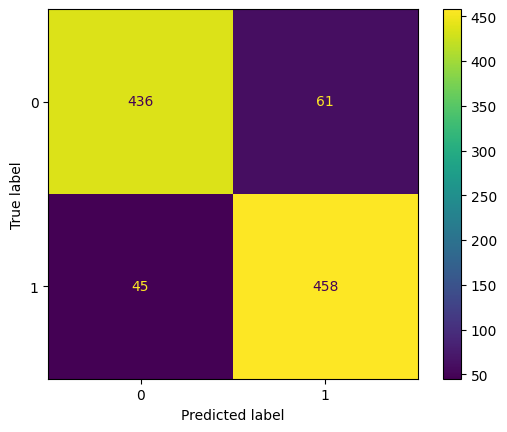

In [11]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
visualizacion.plot();

### Precisión

In [12]:
print(f'La precisión del modelo es :{accuracy_score(y_test, y_pred)}')

La precisión del modelo es :0.894


### Curva ROC

In [13]:
print(roc_curve(y_test, y_pred))

(array([0.        , 0.12273642, 1.        ]), array([0.        , 0.91053678, 1.        ]), array([inf,  1.,  0.]))


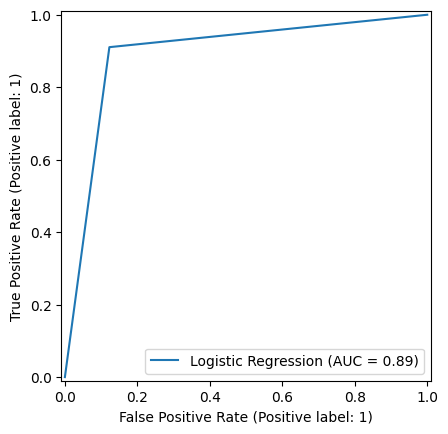

In [14]:
RocCurveDisplay.from_predictions(y_test,y_pred,name='Logistic Regression');

## **Serializamos el modelo**

In [86]:
import pickle

with open('modelo.pkl', 'wb') as archivo:
    pickle.dump(clf, archivo)

## **Cargamos el modelo**


In [88]:
with open('modelo.pkl', 'rb') as archivo:
    clf = pickle.load(archivo)

## **Probabilidades / API**

In [89]:
#Probabilidad de que un cliente se vaya (churn=1)
y_proba = clf.predict_proba(X_test)[:, 1]
y_proba[:10]


array([3.80590617e-05, 9.82798657e-01, 8.60439089e-01, 9.88645567e-01,
       9.91690587e-01, 9.85568817e-01, 9.37351830e-01, 9.99969087e-01,
       3.83984624e-01, 8.23470085e-01])

In [102]:
def predict_cliente(input_dict):
    """
    Documentación de la función
    """
    #df con las caracteristicas del cliente a predecir
    df_input = pd.DataFrame([input_dict])
    #Guardamos la variable id
    id = int(df_input['customer_id'].iloc[0])
    #luego la eliminamos del df para que no intervenga en el modelo
    datos_input = df_input.drop(columns=['customer_id'])
    #corremos el modelo
    proba = clf.predict_proba(datos_input)[0, 1]
    pred = "Va a cancelar" if proba >= 0.5 else "Va a continuar"
    # la salida: id junto con la predicción del modelo
    return {
        "customer_id": id,
        "prediction": pred,
        "probability": round(float(proba), 3)
    }
    
    

## **Función de predicción**

### Probar con un cliente / Manual

In [103]:
cliente_ejemplo = {
    "customer_id": 10,
    "subscription_type": "Standard",
    "watch_hours": 3,
    "last_login_days": 1,
    "monthly_fee": 16,
    "number_of_profiles": 2,
    "avg_watch_time_per_day": 0.35,
    "payment_method": "Debit Card"

}

print(f'La predicción del modelo es:{predict_cliente(cliente_ejemplo)}')


La predicción del modelo es:{'customer_id': 10, 'prediction': 'Va a continuar', 'probability': 0.064}
